# Mushroom Model Final Training

Run `2-Models-Tuning.ipynb` first. This notebook loads its best-parameter pickle, trains the base models and stacking classifier, reports validation/test statistics, and saves fitted estimator pickles.


First we are gonna import all the needed librarys etc

In [23]:
from pathlib import Path
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    GradientBoostingClassifier,
    RandomForestClassifier,
    StackingClassifier,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

after that we are gonna load our data and make the necesary changes after analysing.

In [24]:
# Load the CSV saved in the parent mushrooms folder.
dataset_path = Path('../mushroom_project_dataset.csv')
df = pd.read_csv(dataset_path)

# Remove noise / sparse columns identified during data analysis; ignore missing names safely.
df = df.drop(columns=['jumbled_noise_0', 'jumbled_noise_1', 'spore-print-color'], errors='ignore')
if 'class' not in df.columns:
    raise ValueError("Dataset must contain a 'class' target column.")

X = df.drop(columns='class')
y = df['class'].astype(str)
class_labels = sorted(y.unique())
if len(class_labels) != 2:
    raise ValueError(f'Expected a binary mushroom target, found classes: {class_labels}')

# Stratified 70/20/10 split: reserve test first, then split the other 90%.
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=2/9, random_state=42, stratify=y_train_val
)
print(f'Train: {len(X_train)} rows ({len(X_train) / len(X):.0%})')
print(f'Validation: {len(X_val)} rows ({len(X_val) / len(X):.0%})')
print(f'Test: {len(X_test)} rows ({len(X_test) / len(X):.0%})')
print('Class labels:', class_labels)

# Fit imputation and encoding only inside training folds via model pipelines.
numeric_columns = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_columns = X_train.select_dtypes(exclude=np.number).columns.tolist()

numeric_preprocessing = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
])
categorical_preprocessing = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('one_hot', OneHotEncoder(handle_unknown='ignore', sparse_output=True)),
])
preprocessor = ColumnTransformer([
    ('numeric', numeric_preprocessing, numeric_columns),
    ('categorical', categorical_preprocessing, categorical_columns),
])

Train: 3500 rows (70%)
Validation: 1000 rows (20%)
Test: 500 rows (10%)
Class labels: ['e', 'p']


after that we are gonna train some models, the models that we're gonna train are: 
- Decision tree
- Random forest
- Gradiant boosting
- XGBoost

after this we're gonna use stacking with all the models.

## Train, validate, and export models

Estimator settings are loaded from `models/best_model_parameters.pkl` and applied unchanged to each base model. The stacking model uses those tuned base estimators. Validation and held-out test metrics are reported separately. Pickles should only be loaded from sources you trust.


Loaded tuned parameters from: C:\school\AI\Deep Learning\Cloud_AI\CloudAI-Challenge\mushrooms\Cisse\models\best_model_parameters.pkl
Validation metrics (e = edible, p = poisonous):


,accuracy,edible_precision,edible_recall,poisonous_recall
random_forest,0.776,0.788,0.874,0.615
xgboost,0.767,0.753,0.931,0.499
stacking,0.765,0.811,0.810,0.691
gradient_boosting,0.736,0.717,0.948,0.388
decision_tree,0.725,0.749,0.839,0.538


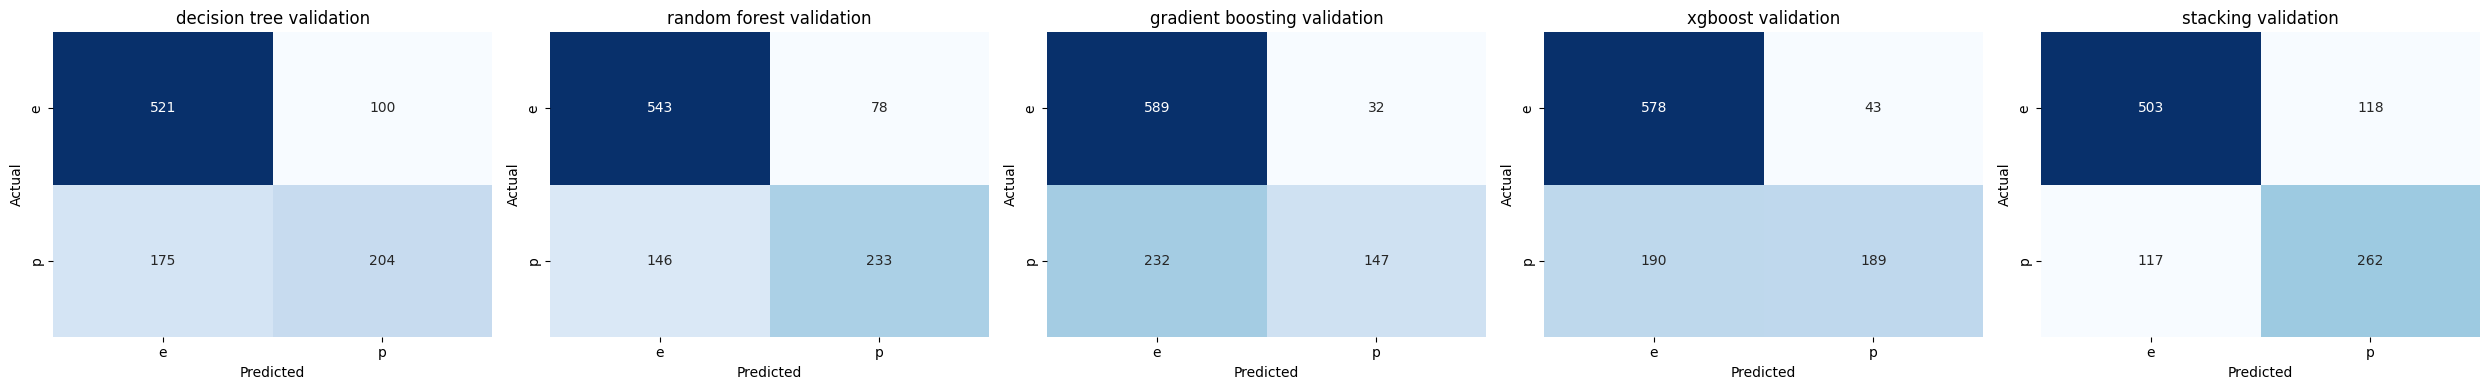

Held-out test metrics (e = edible, p = poisonous):


,accuracy,edible_precision,edible_recall,poisonous_recall
random_forest,0.794,0.802,0.887,0.640
stacking,0.792,0.837,0.826,0.735
xgboost,0.774,0.748,0.961,0.466
gradient_boosting,0.758,0.729,0.971,0.407
decision_tree,0.728,0.741,0.865,0.503


Accuracy by model (validation and held-out test):
                   validation_accuracy  test_accuracy
random_forest                    0.776          0.794
stacking                         0.765          0.792
xgboost                          0.767          0.774
gradient_boosting                0.736          0.758
decision_tree                    0.725          0.728
Saved 5 fitted model pickle files and model outputs to: C:\school\AI\Deep Learning\Cloud_AI\CloudAI-Challenge\mushrooms\Cisse\models


In [25]:
# Load hyperparameters produced by 2-Models-Tuning.ipynb.
output_dir = Path('models')
parameter_path = output_dir / 'best_model_parameters.pkl'
if not parameter_path.exists():
    raise FileNotFoundError(
        f'{parameter_path} not found. Run 2-Models-Tuning.ipynb first to create the parameter pickle.'
    )
with parameter_path.open('rb') as parameter_file:
    tuning_results = pickle.load(parameter_file)
if tuning_results.get('format_version') != 1:
    raise ValueError('Unsupported or invalid model parameter pickle format.')
required_models = {'decision_tree', 'random_forest', 'gradient_boosting', 'xgboost'}
if set(tuning_results.get('best_params', {})) != required_models:
    raise ValueError('The tuning pickle must contain parameters for all four base models.')
if tuning_results.get('feature_columns') != X.columns.tolist():
    raise ValueError('Tuning parameters were generated for a different feature set.')
best_params = tuning_results['best_params']
print('Loaded tuned parameters from:', parameter_path.resolve())

# Define each base estimator. Pipelines keep preprocessing attached to the fitted model.
base_estimators = {
    'decision_tree': DecisionTreeClassifier(
        max_depth=15, min_samples_leaf=2, class_weight='balanced', random_state=42
    ),
    'random_forest': RandomForestClassifier(
        n_estimators=100, max_depth=None, min_samples_split=5, min_samples_leaf=1,
        class_weight='balanced', n_jobs=-1, random_state=42, max_features='sqrt'
    ),
    'gradient_boosting': GradientBoostingClassifier(
        n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42
    ),
    'xgboost': XGBClassifier(
        n_estimators=100, max_depth=4, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', n_jobs=-1, random_state=42
    ),
}

models = {
    name: Pipeline([
        ('preprocessor', clone(preprocessor)),
        ('classifier', estimator),
    ])
    for name, estimator in base_estimators.items()
}

for name, model in models.items():
    model.set_params(**best_params[name])

stacking_estimators = [
    (name, clone(model)) for name, model in models.items()
]
models['stacking'] = StackingClassifier(
    estimators=stacking_estimators,
    final_estimator=LogisticRegression(max_iter=1000, class_weight='balanced'),
    cv=5,
    n_jobs=-1,
)

# Target mapping for XGBoost compatibility: Map 'e' -> 0, 'p' -> 1
label_map = {label: idx for idx, label in enumerate(class_labels)}
y_train_encoded = np.array([label_map[val] for val in y_train])
y_val_encoded = np.array([label_map[val] for val in y_val])
y_test_encoded = np.array([label_map[val] for val in y_test])
encoded_labels = [label_map[label] for label in class_labels]

# Fit on training data and calculate validation metrics for every model.
validation_metrics = {}
validation_predictions = {}
for name, model in models.items():
    model.fit(X_train, y_train_encoded)
    predictions = model.predict(X_val)
    validation_predictions[name] = predictions
    
    # Generate classification report mapped back to original class names ('e', 'p')
    report = classification_report(
        y_val_encoded, predictions, labels=encoded_labels, 
        target_names=class_labels, output_dict=True, zero_division=0
    )
    
    validation_metrics[name] = {
        'accuracy': accuracy_score(y_val_encoded, predictions),
        'classification_report': report,
        'confusion_matrix': confusion_matrix(y_val_encoded, predictions, labels=encoded_labels),
    }

validation_summary = pd.DataFrame({
    name: {
        'accuracy': metrics['accuracy'],
        'edible_precision': metrics['classification_report'].get('e', {}).get('precision', np.nan),
        'edible_recall': metrics['classification_report'].get('e', {}).get('recall', np.nan),
        'poisonous_recall': metrics['classification_report'].get('p', {}).get('recall', np.nan),
    }
    for name, metrics in validation_metrics.items()
}).T.sort_values('accuracy', ascending=False)

print('Validation metrics (e = edible, p = poisonous):')
display(validation_summary.style.format('{:.3f}'))

fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 4))
if len(models) == 1:
    axes = [axes]

for ax, (name, metrics) in zip(axes, validation_metrics.items()):
    sns.heatmap(
        metrics['confusion_matrix'], annot=True, fmt='d', cmap='Blues', cbar=False,
        xticklabels=class_labels, yticklabels=class_labels, ax=ax,
    )
    ax.set(title=f'{name.replace("_", " ")} validation', xlabel='Predicted', ylabel='Actual')
plt.tight_layout()
plt.show()

# Final held-out test comparison; do not use these results to tune or choose cutoffs.
test_metrics = {}
test_predictions = {}
for name, model in models.items():
    predictions = model.predict(X_test)
    test_predictions[name] = predictions
    
    report = classification_report(
        y_test_encoded, predictions, labels=encoded_labels, 
        target_names=class_labels, output_dict=True, zero_division=0
    )
    
    test_metrics[name] = {
        'accuracy': accuracy_score(y_test_encoded, predictions),
        'classification_report': report,
        'confusion_matrix': confusion_matrix(y_test_encoded, predictions, labels=encoded_labels),
    }

test_summary = pd.DataFrame({
    name: {
        'accuracy': metrics['accuracy'],
        'edible_precision': metrics['classification_report'].get('e', {}).get('precision', np.nan),
        'edible_recall': metrics['classification_report'].get('e', {}).get('recall', np.nan),
        'poisonous_recall': metrics['classification_report'].get('p', {}).get('recall', np.nan),
    }
    for name, metrics in test_metrics.items()
}).T.sort_values('accuracy', ascending=False)

print('Held-out test metrics (e = edible, p = poisonous):')
display(test_summary.style.format('{:.3f}'))

# Print accuracy for every individual model and the stacking model.
accuracy_summary = pd.DataFrame({
    'validation_accuracy': {
        name: metrics['accuracy'] for name, metrics in validation_metrics.items()
    },
    'test_accuracy': {
        name: metrics['accuracy'] for name, metrics in test_metrics.items()
    },
}).sort_values('test_accuracy', ascending=False)

print('Accuracy by model (validation and held-out test):')
print(accuracy_summary.to_string(float_format=lambda value: f'{value:.3f}'))

# Save each fitted estimator, plus a complete bundle with split metrics and predictions.
output_dir = Path('models')
output_dir.mkdir(parents=True, exist_ok=True)
for name, model in models.items():
    with (output_dir / f'{name}.pkl').open('wb') as model_file:
        pickle.dump(model, model_file, protocol=pickle.HIGHEST_PROTOCOL)

model_outputs = {
    'class_labels': class_labels,
    'label_map': label_map,
    'feature_columns': X.columns.tolist(),
    'best_params': best_params,
    'best_cv_scores': tuning_results['best_cv_scores'],
    'validation_metrics': validation_metrics,
    'test_metrics': test_metrics,
    'validation_predictions': validation_predictions,
    'test_predictions': test_predictions,
}
with (output_dir / 'mushroom_model_outputs.pkl').open('wb') as outputs_file:
    pickle.dump(model_outputs, outputs_file, protocol=pickle.HIGHEST_PROTOCOL)

print(f'Saved {len(models)} fitted model pickle files and model outputs to: {output_dir.resolve()}')